Лабораторная работа №4
=
    
**Проведение исследований со случайным лесом**

Классификация
=

**Импорт необходимых библиотек**

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, classification_report, confusion_matrix
from sklearn.utils import resample
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

**Визуализация распределения**

Распределение целевой переменной 'fail':
fail
0    551
1    393
Name: count, dtype: int64


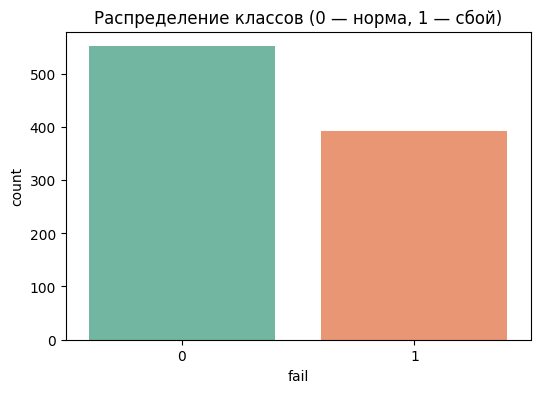

In [17]:
df = pd.read_csv('data_class.csv')

columns = ['footfall', 'tempMode', 'AQ', 'USS', 'CS', 'VOC', 'RP', 'IP', 'Temperature', 'fail']
df.columns = columns

print("Распределение целевой переменной 'fail':")
print(df['fail'].value_counts())

plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='fail', palette='Set2')
plt.title('Распределение классов (0 — норма, 1 — сбой)')
plt.show()

**Логарифмирование признаков и создание новых**

In [18]:
log_cols = ['footfall', 'VOC', 'USS', 'CS', 'IP']
for col in log_cols:
    df[col] = np.log1p(df[col])

df['sensor_ratio'] = df['AQ'] / (df['Temperature'] + 1e-6)
df['is_high_risk'] = (
    (df['VOC'] > df['VOC'].quantile(0.85)) & 
    (df['Temperature'] > df['Temperature'].quantile(0.85))
).astype(int)

**Создание бейзлайна**

In [19]:
X = df.drop('fail', axis=1)
y = df['fail']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

rf_bl = RandomForestClassifier(random_state=42)
rf_bl.fit(X_train, y_train)
y_pred_bl = rf_bl.predict(X_test)

acc_bl = accuracy_score(y_test, y_pred_bl)
f1_bl = f1_score(y_test, y_pred_bl)
roc_bl = roc_auc_score(y_test, rf_bl.predict_proba(X_test)[:, 1])

print(f"Accuracy: {acc_bl:.4f} | F1: {f1_bl:.4f} | ROC-AUC: {roc_bl:.4f}")

Accuracy: 0.9153 | F1: 0.8987 | ROC-AUC: 0.9764


**Улучшение бейзлайна**

In [20]:
param_grid = {
    'n_estimators': [200, 300],
    'max_depth': [10, 15, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 5],
    'max_features': ['sqrt'],
    'class_weight': ['balanced']
}

grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=3,
    scoring='f1',
    n_jobs=-1
)
grid.fit(X_train, y_train)

y_proba = grid.predict_proba(X_test)[:, 1]
best_f1, best_thresh = 0, 0.5
for thresh in np.arange(0.1, 0.9, 0.01):
    y_pred = (y_proba >= thresh).astype(int)
    f1 = f1_score(y_test, y_pred)
    if f1 > best_f1:
        best_f1, best_thresh = f1, thresh

y_pred_final = (y_proba >= best_thresh).astype(int)
acc_final = accuracy_score(y_test, y_pred_final)
f1_final = best_f1

print(f"Accuracy: {acc_final:.4f} | F1: {f1_final:.4f}")
print(f"Лучший порог: {best_thresh:.2f}")
print(f"Лучшие параметры: {grid.best_params_}")

Accuracy: 0.9206 | F1: 0.9112
Лучший порог: 0.34
Лучшие параметры: {'class_weight': 'balanced', 'max_depth': 15, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 10, 'n_estimators': 300}


**Визуализация важности признаков**

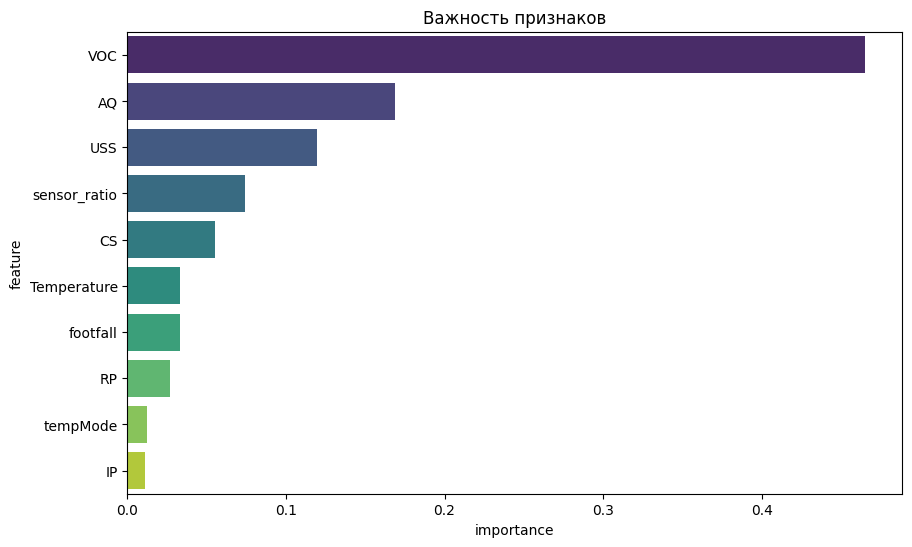

In [21]:
importances = grid.best_estimator_.feature_importances_
feat_imp = pd.DataFrame({
    'feature': X.columns,
    'importance': importances
}).sort_values(by='importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=feat_imp.head(10), x='importance', y='feature', palette='viridis')
plt.title('Важность признаков')
plt.show()

**Собственная реализация решающего дерева(взято с прошлой ЛР)**

In [22]:
class MyDecisionTreeClassifier:
    def __init__(self, max_depth=5):
        self.max_depth = max_depth
        self.tree = None

    def _gini(self, y):
        m = len(y)
        if m == 0: return 0
        return 1 - sum((np.sum(y == c) / m) ** 2 for c in np.unique(y))

    def _best_split(self, X, y):
        best_gini, best_feature, best_threshold = 1, None, None
        for feature in range(X.shape[1]):
            thresholds = np.unique(X[:, feature])
            for th in thresholds:
                left = X[:, feature] <= th
                right = ~left
                if np.sum(left) == 0 or np.sum(right) == 0: continue
                gini = (np.sum(left) * self._gini(y[left]) + np.sum(right) * self._gini(y[right])) / len(y)
                if gini < best_gini:
                    best_gini, best_feature, best_threshold = gini, feature, th
        return best_feature, best_threshold

    def _build_tree(self, X, y, depth=0):
        if depth >= self.max_depth or len(np.unique(y)) == 1:
            return {'class': np.bincount(y).argmax()}
        feature, threshold = self._best_split(X, y)
        if feature is None: return {'class': np.bincount(y).argmax()}
        left_mask = X[:, feature] <= threshold
        return {
            'feature': feature,
            'threshold': threshold,
            'left': self._build_tree(X[left_mask], y[left_mask], depth + 1),
            'right': self._build_tree(X[~left_mask], y[~left_mask], depth + 1)
        }

    def fit(self, X, y):
        self.tree = self._build_tree(np.array(X), np.array(y))

    def _predict_sample(self, x, tree):
        if 'class' in tree: return tree['class']
        if x[tree['feature']] <= tree['threshold']:
            return self._predict_sample(x, tree['left'])
        else:
            return self._predict_sample(x, tree['right'])

    def predict(self, X):
        return np.array([self._predict_sample(x, self.tree) for x in np.array(X)])

**Реализация рандомного леса**

In [23]:
class MyRandomForestClassifier:
    def __init__(self, n_estimators=10, max_depth=5, random_state=42):
        self.n_estimators = n_estimators
        self.max_depth = max_depth
        self.random_state = random_state
        self.trees = []

    def fit(self, X, y):
        np.random.seed(self.random_state)
        self.trees = []
        for _ in range(self.n_estimators):
            X_boot, y_boot = resample(X, y, random_state=np.random.randint(0, 10000))
            tree = MyDecisionTreeClassifier(max_depth=self.max_depth)
            tree.fit(X_boot, y_boot)
            self.trees.append(tree)

    def predict(self, X):
        predictions = np.array([tree.predict(X) for tree in self.trees])
        final_pred = []
        for i in range(X.shape[0]):
            votes = predictions[:, i]
            final_pred.append(np.bincount(votes).argmax())
        return np.array(final_pred)

**Обучение собственной модели на данных бейзлайна**

In [27]:
my_forest = MyRandomForestClassifier(n_estimators=20, max_depth=10, random_state=42)
my_forest.fit(X_train, y_train)
y_pred_custom_base = my_forest.predict(X_test)

acc_custom_base = accuracy_score(y_test, y_pred_custom_base)
f1_custom_base = f1_score(y_test, y_pred_custom_base)

print(f"Accuracy: {acc_custom_base:.4f} | F1: {f1_custom_base:.4f}")

Accuracy: 0.8836 | F1: 0.8625


**Обучение улучшенной собственной реализации**

In [30]:
my_forest = MyRandomForestClassifier(n_estimators=3, max_depth=15, random_state=42)
my_forest.fit(X_train, y_train)
y_pred_custom = my_forest.predict(X_test)

acc_custom = accuracy_score(y_test, y_pred_custom)
f1_custom = f1_score(y_test, y_pred_custom)

print(f"Accuracy: {acc_custom:.4f} | F1: {f1_custom:.4f}")

Accuracy: 0.8942 | F1: 0.8765


**Вывод результатов**

In [77]:
results = pd.DataFrame({
    'Модель': [
        'Бейзлайн',
        'Улучшенная модель',
        'Собственная реализация начальная',
        'Собственная реализация улучшенная'
    ],
    'Accuracy': [acc_bl, acc_final, acc_custom_base, acc_custom],
    'F1': [f1_bl, f1_final, f1_custom_base, f1_custom]
})
results

,Модель,Accuracy,F1
0,Бейзлайн,0.915344,0.898734
1,Улучшенная модель,0.920635,0.911243
2,Собственная реализация начальная,0.883598,0.862500
3,Собственная реализация улучшенная,0.894180,0.876543


Регрессия
=

**Импорт необходимых библиотек**

In [57]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score
import warnings
warnings.filterwarnings('ignore')

**Загрузка датасета и фильтрация данных**

In [58]:
df = pd.read_csv('data.csv', header=None)
columns = [
    'price', 'building_type', 'district', 'floor', 'city',
    'rooms', 'total_area', 'living_area', 'kitchen_area', 'balcony',
    'floor_level', 'renovation'
]
df.columns = columns

numeric_cols = ['price', 'floor', 'rooms', 'total_area', 'living_area', 'kitchen_area', 'balcony', 'floor_level']
df[numeric_cols] = df[numeric_cols].apply(pd.to_numeric, errors='coerce')
df = df.dropna(subset=['price'])

df = df[df['price'] <= 120_000_000]
df = df[(df['total_area'] > 10) & (df['total_area'] <= 300)]
df = df[df['rooms'] > 0]

print(f"Объектов после фильтрации: {len(df)}")

Объектов после фильтрации: 17356


**Создание новых признаков и One-Hot encoding**

In [59]:
df['floor_ratio'] = df['floor'] / df['floor_level']
df['area_per_room'] = df['total_area'] / df['rooms']

df = pd.get_dummies(df, columns=['district', 'renovation'], drop_first=True)

df['log_price'] = np.log(df['price'])

print(f"Число признаков после One-Hot: {df.shape[1] - 2}")

Число признаков после One-Hot: 527


**Обучение бейзлайна**

In [60]:
numeric_features = ['total_area', 'living_area', 'kitchen_area', 'floor', 'area_per_room', 'floor_ratio']
X_all = df[numeric_features]
y_all = df['log_price']

X_train, X_test, y_train, y_test = train_test_split(X_all, y_all, test_size=0.2, random_state=42)

rf_bl = RandomForestRegressor(random_state=42)
rf_bl.fit(X_train, y_train)
y_pred_bl = rf_bl.predict(X_test)

r2_bl = r2_score(y_test, y_pred_bl)
mae_bl = mean_absolute_error(np.exp(y_test), np.exp(y_pred_bl))

print(f"MAE: {mae_bl:,.0f} руб. | R²: {r2_bl:.4f}")
print(f"Количество деревьев: {rf_bl.n_estimators}")
print(f"Макс. глубина: {rf_bl.max_depth}")

MAE: 4,108,591 руб. | R²: 0.8909
Количество деревьев: 100
Макс. глубина: None


**Улучшение бейзлайна**

In [40]:
feature_cols = [col for col in df.columns if col not in ['price', 'log_price', 'building_type', 'city']]
X_imp = df[feature_cols]
y_imp = df['log_price']

X_train_imp, X_test_imp, y_train_imp, y_test_imp = train_test_split(X_imp, y_imp, test_size=0.2, random_state=42)

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [10, 15, 20, None],
    'min_samples_split': [2, 5, 10],
    'max_features': ['sqrt', 'log2', None]
}

grid = GridSearchCV(
    RandomForestRegressor(random_state=42),
    param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1
)
grid.fit(X_train_imp, y_train_imp)

y_pred_imp = grid.predict(X_test_imp)
r2_imp = r2_score(y_test_imp, y_pred_imp)
mae_imp = mean_absolute_error(np.exp(y_test_imp), np.exp(y_pred_imp))

print(f"MAE: {mae_imp:,.0f} руб. | R²: {r2_imp:.4f}")
print(f"Лучшие параметры: {grid.best_params_}")

MAE: 3,153,545 руб. | R²: 0.9480
Лучшие параметры: {'max_depth': None, 'max_features': 'log2', 'min_samples_split': 2, 'n_estimators': 200}


**Визуализация важности признаков**

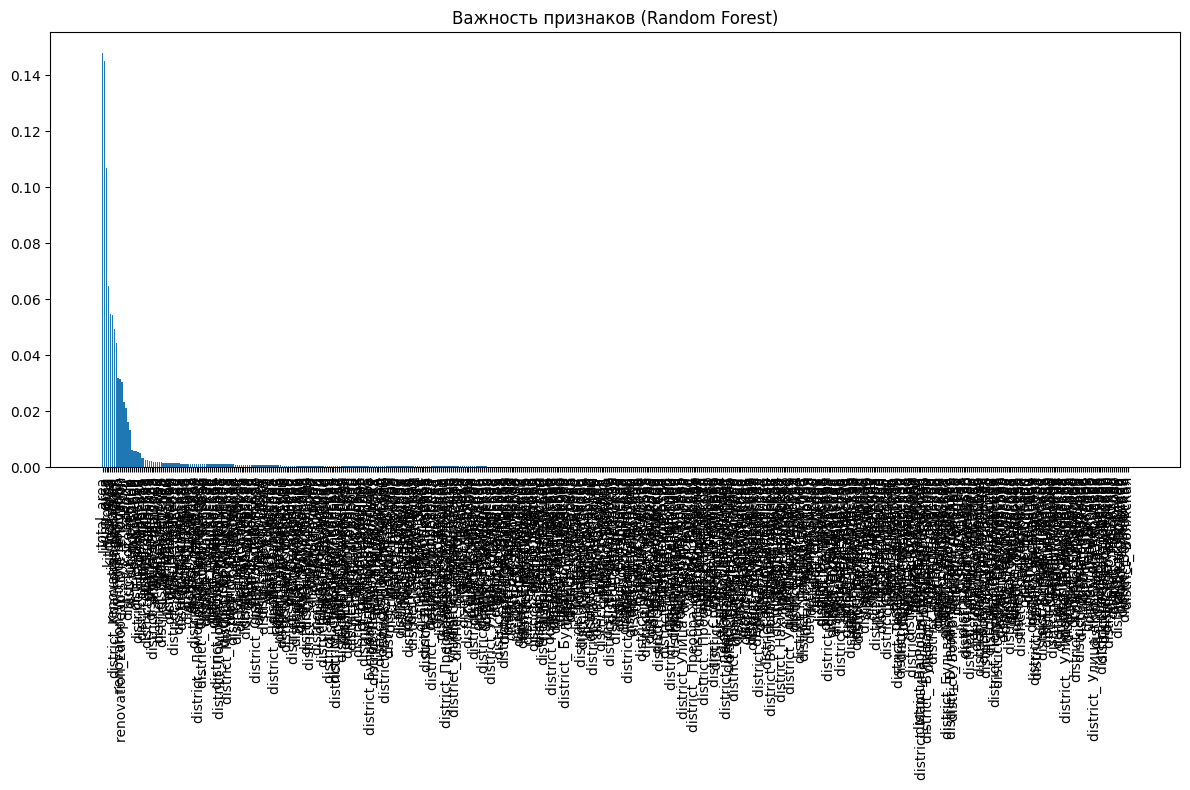

In [41]:
importances = grid.best_estimator_.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(12, 8))
plt.title("Важность признаков (Random Forest)")
plt.bar(range(len(feature_cols)), importances[indices], align="center")
plt.xticks(range(len(feature_cols)), [feature_cols[i] for i in indices], rotation=90)
plt.tight_layout()
plt.show()

**Собственная реализация (класс MyDecisionTreeRegressor взять с прошлой ЛР)**

In [64]:
from sklearn.tree import DecisionTreeRegressor

class MyRandomForestRegressor:
    def __init__(self, n_estimators=10, max_depth=5, random_state=42):
        self.n_estimators = n_estimators
        self.max_depth = max_depth
        self.random_state = random_state
        self.trees = []

    def fit(self, X, y):
        np.random.seed(self.random_state)
        self.trees = []
        for i in range(self.n_estimators):
            indices = np.random.choice(len(X), size=len(X), replace=True)
            X_boot, y_boot = X[indices], y[indices]
            tree = DecisionTreeRegressor(
                max_depth=self.max_depth,
                max_features='sqrt',
                random_state=self.random_state + i
            )
            tree.fit(X_boot, y_boot)
            self.trees.append(tree)

    def predict(self, X):
        predictions = np.array([tree.predict(X) for tree in self.trees])
        return np.mean(predictions, axis=0)

**Обучение собственной слабой модели**

In [72]:
my_forest = MyRandomForestRegressor(random_state=42)
my_forest.fit(X_train.values, y_train.values)  

y_pred_custom_base = my_forest.predict(X_test.values)

r2_custom_base = r2_score(y_test, y_pred_custom_base)
mae_custom_base = mean_absolute_error(np.exp(y_test), np.exp(y_pred_custom_base))

print(f"MAE: {mae_custom_base:,.0f} руб. | R²: {r2_custom_base:.4f}")

MAE: 6,718,906 руб. | R²: 0.7053


**Обучение собственной сильной модели**

In [75]:
my_forest = MyRandomForestRegressor(n_estimators=200, max_depth=None, random_state=42)
my_forest.fit(X_train_imp.values, y_train_imp.values)
y_pred_custom = my_forest.predict(X_test_imp.values)

r2_custom = r2_score(y_test_imp, y_pred_custom)
mae_custom = mean_absolute_error(np.exp(y_test_imp), np.exp(y_pred_custom))

print(f"MAE: {mae_custom:,.0f} руб. | R²: {r2_custom:.4f}")

MAE: 3,288,245 руб. | R²: 0.9422


**Таблица результатов**

In [78]:
results = pd.DataFrame({
    'Модель': ['Бейзлайн', 'Улучшенная модель', 'Собственная реализация слабая', 'Собственная реализация сильная'],
    'MAE (руб.)': [mae_bl, mae_imp, mae_custom_base, mae_custom],
    'R²': [r2_bl, r2_imp, r2_custom_base, r2_custom]
})
results

,Модель,MAE (руб.),R²
0,Бейзлайн,4.108591e+06,0.890932
1,Улучшенная модель,3.153545e+06,0.947996
2,Собственная реализация слабая,6.718906e+06,0.705345
3,Собственная реализация сильная,3.288245e+06,0.942234
